# [LAB-02] 비지도학습 > 군집분석 > KMeans ㅣ Base Model

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helper import *

from pandas import DataFrame

# 군집분석 관련 참조
from sklearn.cluster import KMeans, MiniBatchKMeans

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 가져오기 - 게임 유저 군집화

In [2]:
origin = load_data("game_usage")
origin.head()

📚 게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,39,944
1,55,705
2,29,757
3,59,999
4,7,109


## #02. 데이터 살펴보기

### 1. 게임 이용자의 시간과 레벨 분포 확인

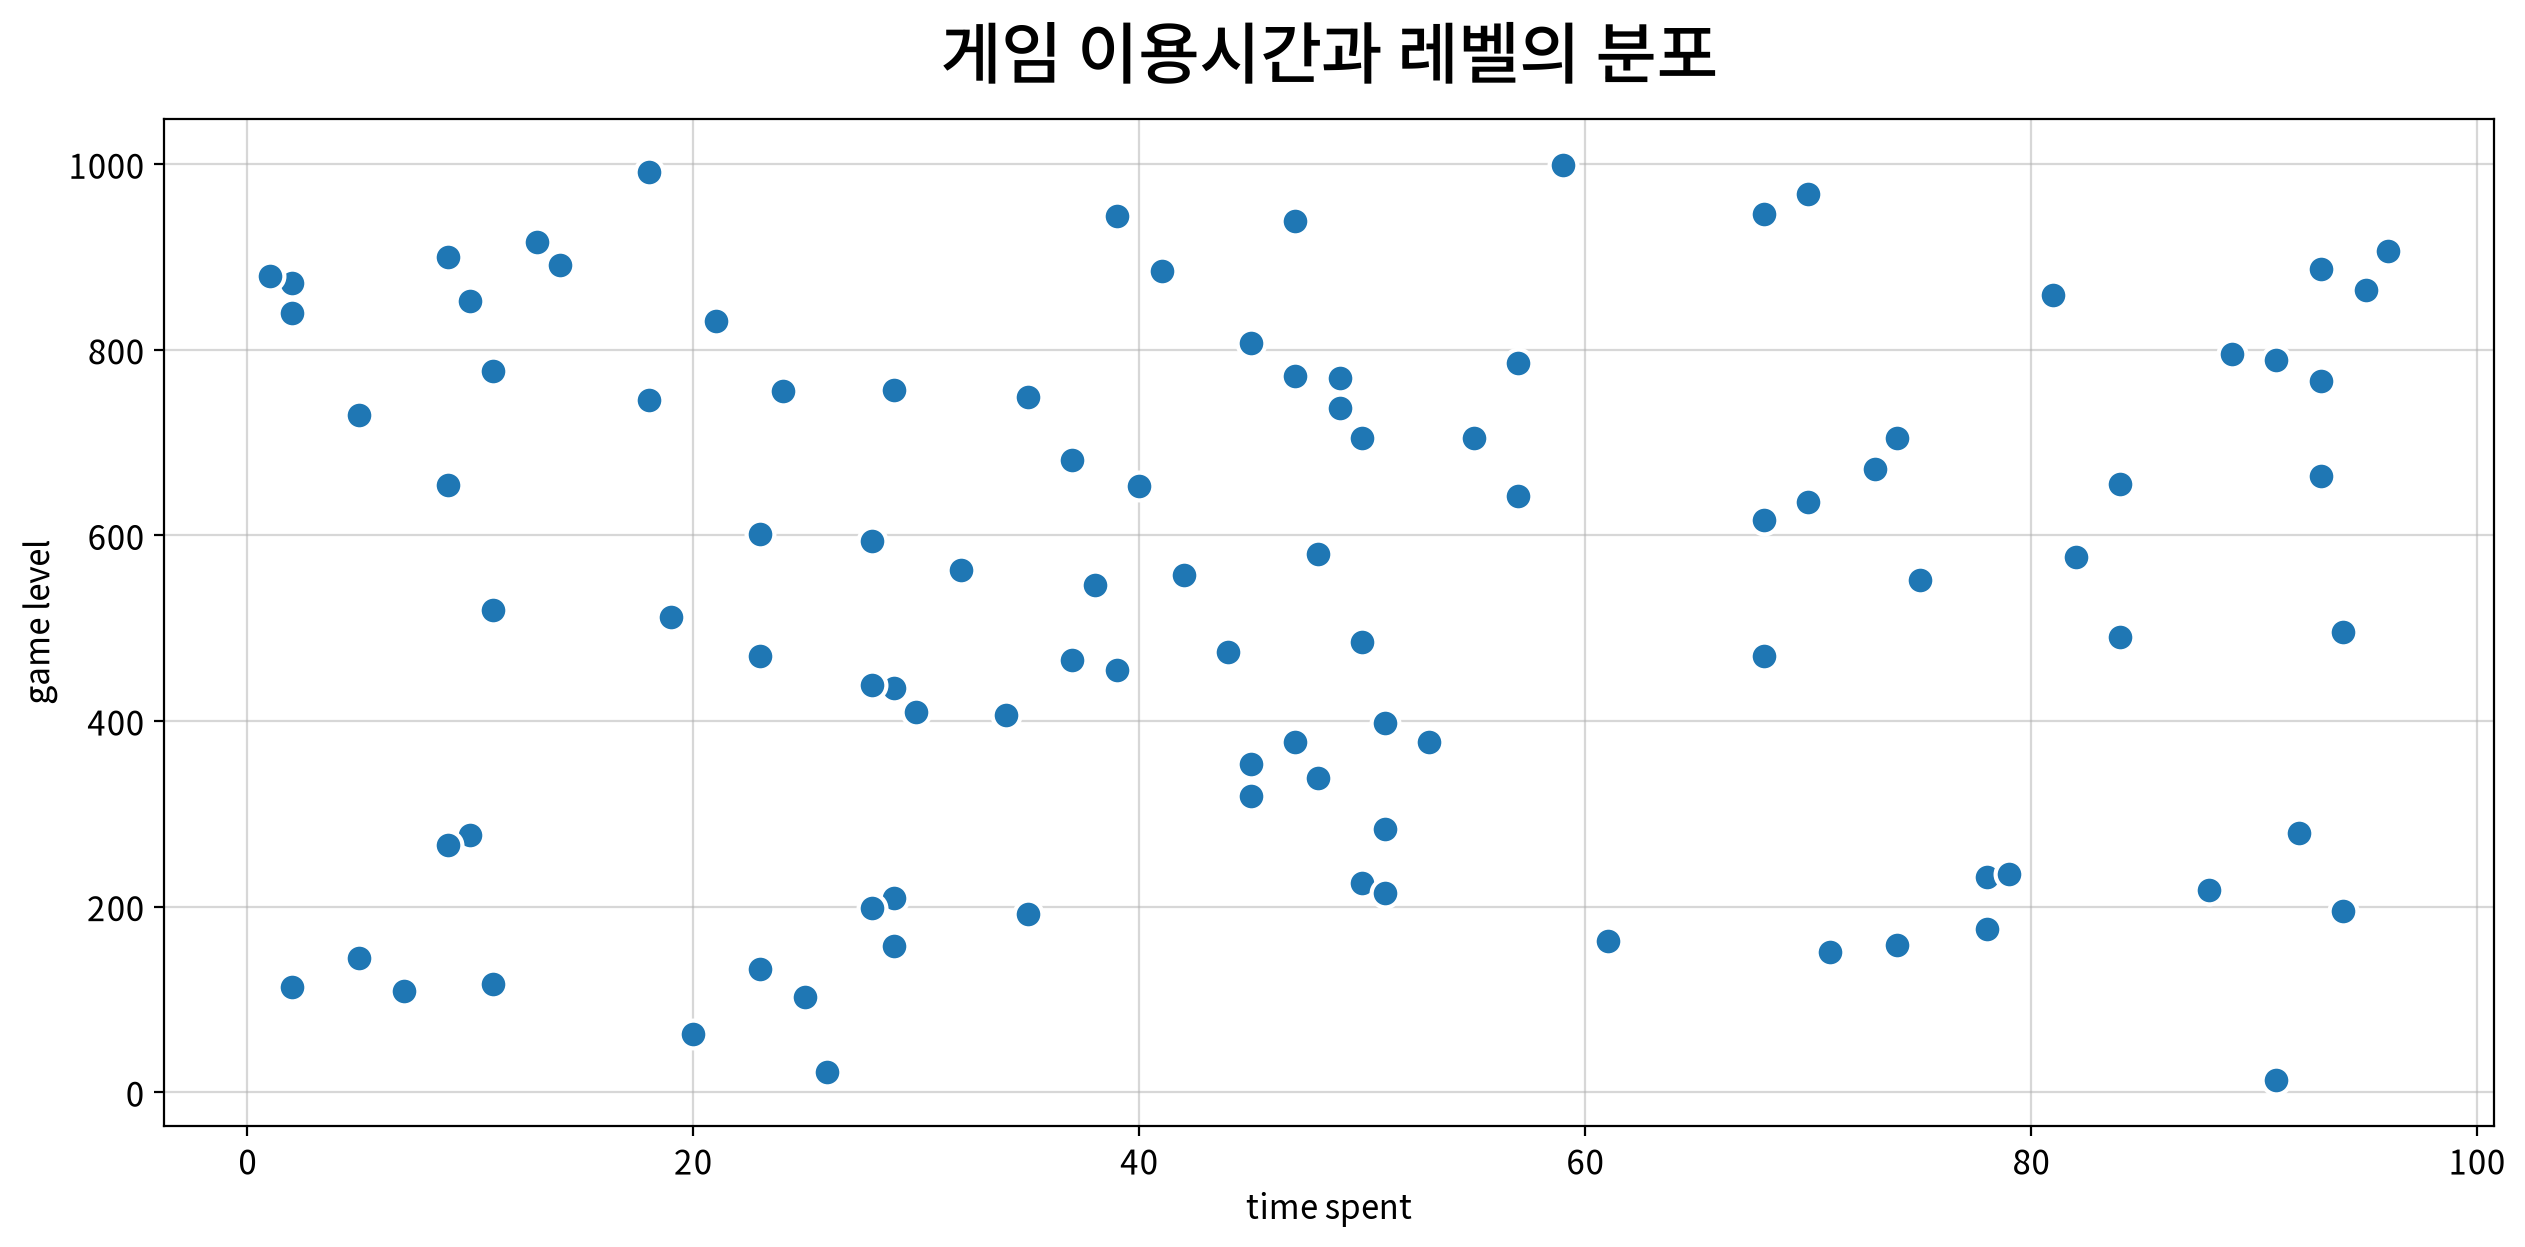

In [3]:
my_plot.scatterplot(data=origin, x='time spent', y='game level', title="게임 이용시간과 레벨의 분포" )

## #03. 그룹화(Clustering)

### 1. 4개 그룹으로 군집화

In [4]:
# 모델 객체 생성 (그룹을 4개로 나눠 달라고 지시)
# RANDOM_STATE는 /helpers/__init__.py에 정의되어 있음
estimator = KMeans(n_clusters=4, random_state=RANDOM_STATE)

# 모델 학습 (중심점을 찾는 과정)
estimator.fit(origin)

# 각 데이터가 몇 번 그룹인지 확인
cluster_pred = estimator.predict(origin)
cluster_pred

array([2, 1, 1, 2, 0, 1, 3, 3, 0, 3, 2, 1, 0, 3, 2, 0, 1, 0, 2, 3, 1, 2,
       0, 1, 0, 2, 1, 0, 3, 3, 1, 1, 3, 0, 1, 1, 3, 0, 0, 2, 0, 1, 2, 1,
       2, 1, 1, 3, 1, 0, 3, 0, 0, 0, 3, 2, 0, 1, 2, 3, 0, 1, 3, 3, 3, 1,
       3, 0, 3, 1, 2, 3, 0, 0, 2, 0, 2, 1, 0, 3, 0, 1, 3, 2, 0, 3, 1, 3,
       0, 0, 1, 1, 3, 1, 2, 2, 3, 2, 0, 3], dtype=int32)

### 2. 결과를 데이터프레임으로 구성

In [5]:
df = origin.copy()
df["그룹번호"] = cluster_pred
df.head()

,time spent,game level,그룹번호
0,39,944,2
1,55,705,1
2,29,757,1
3,59,999,2
4,7,109,0


### 3. 결과 시각화

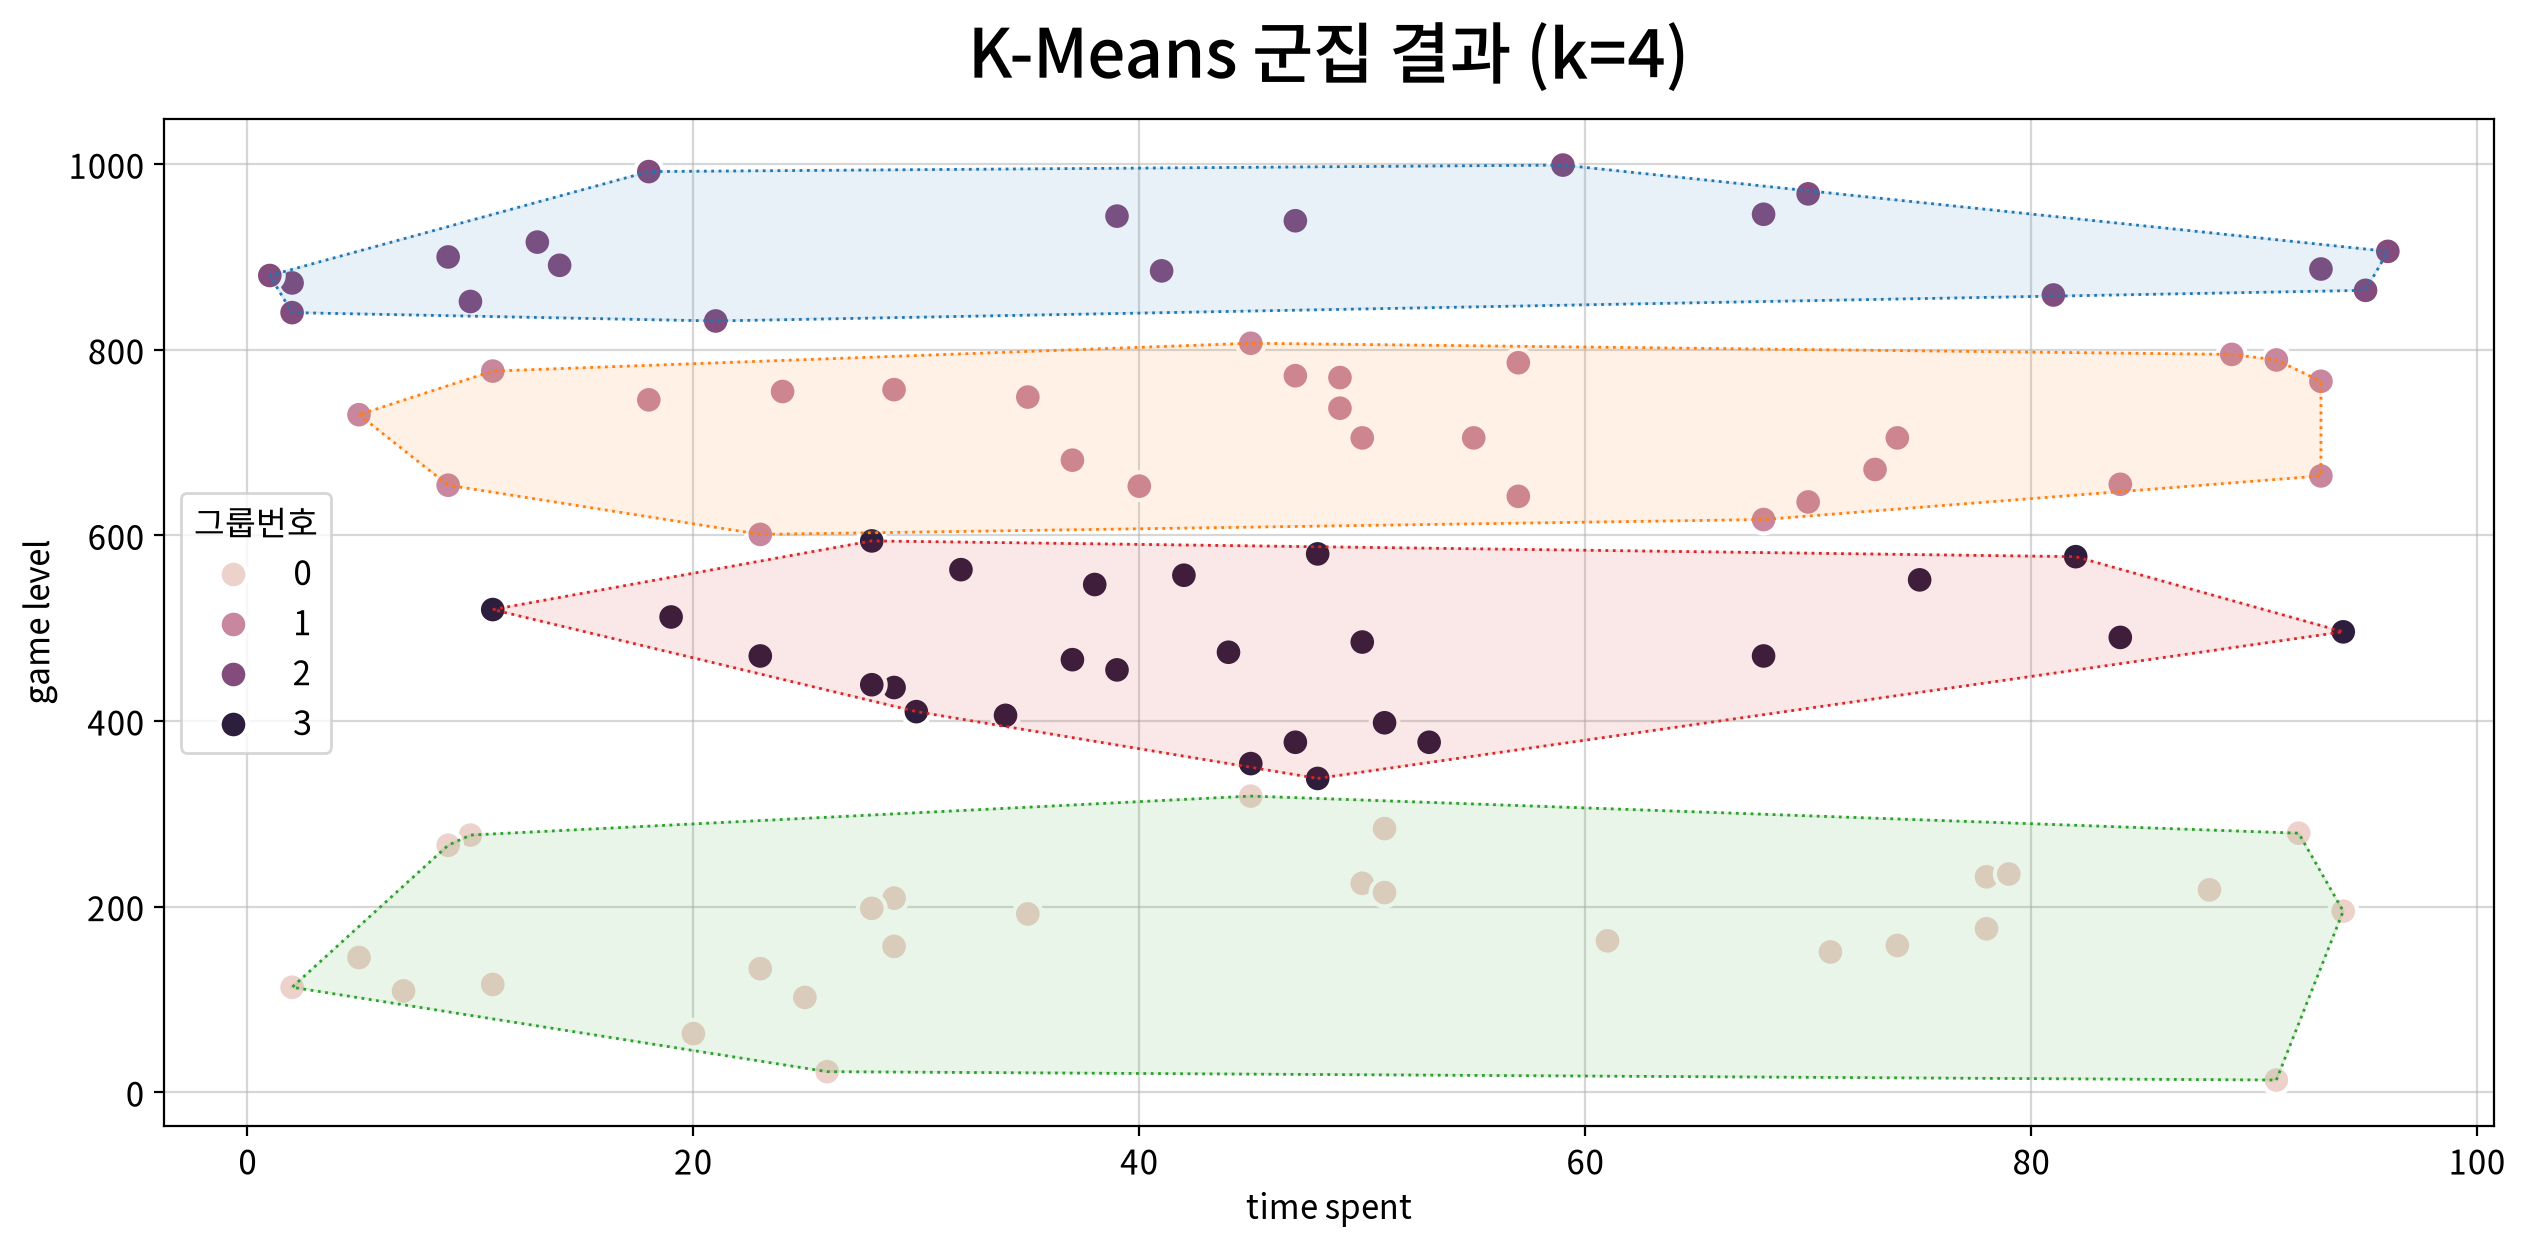

In [6]:
my_plot.scatterplot(data=df, x="time spent", y="game level", hue="그룹번호", outline=True, title="K-Means 군집 결과 (k=4)")

### 4. 모델이 찾은 중심점

- 각 군집별 중심점의 좌표를 확인할 수 있다.
  - `[x좌표, y좌표]`형태를 포함하는 2차원 리스트

In [7]:
center_df = DataFrame(estimator.cluster_centers_, columns=["x","y"])

center_df

,x,y
0,45.071,177.321
1,50.926,715.741
2,41.000,903.737
3,45.346,474.731


### 5. 군집 결과 시각화 + 중심점 표시

- 시각화 결과물에 여기에 모델이 찾아낸 **중심점(`cluster_centers_`)** 을 빨간 `X`로 덧그리면 K-Means가 무엇을 했는지 한눈에 보인다.

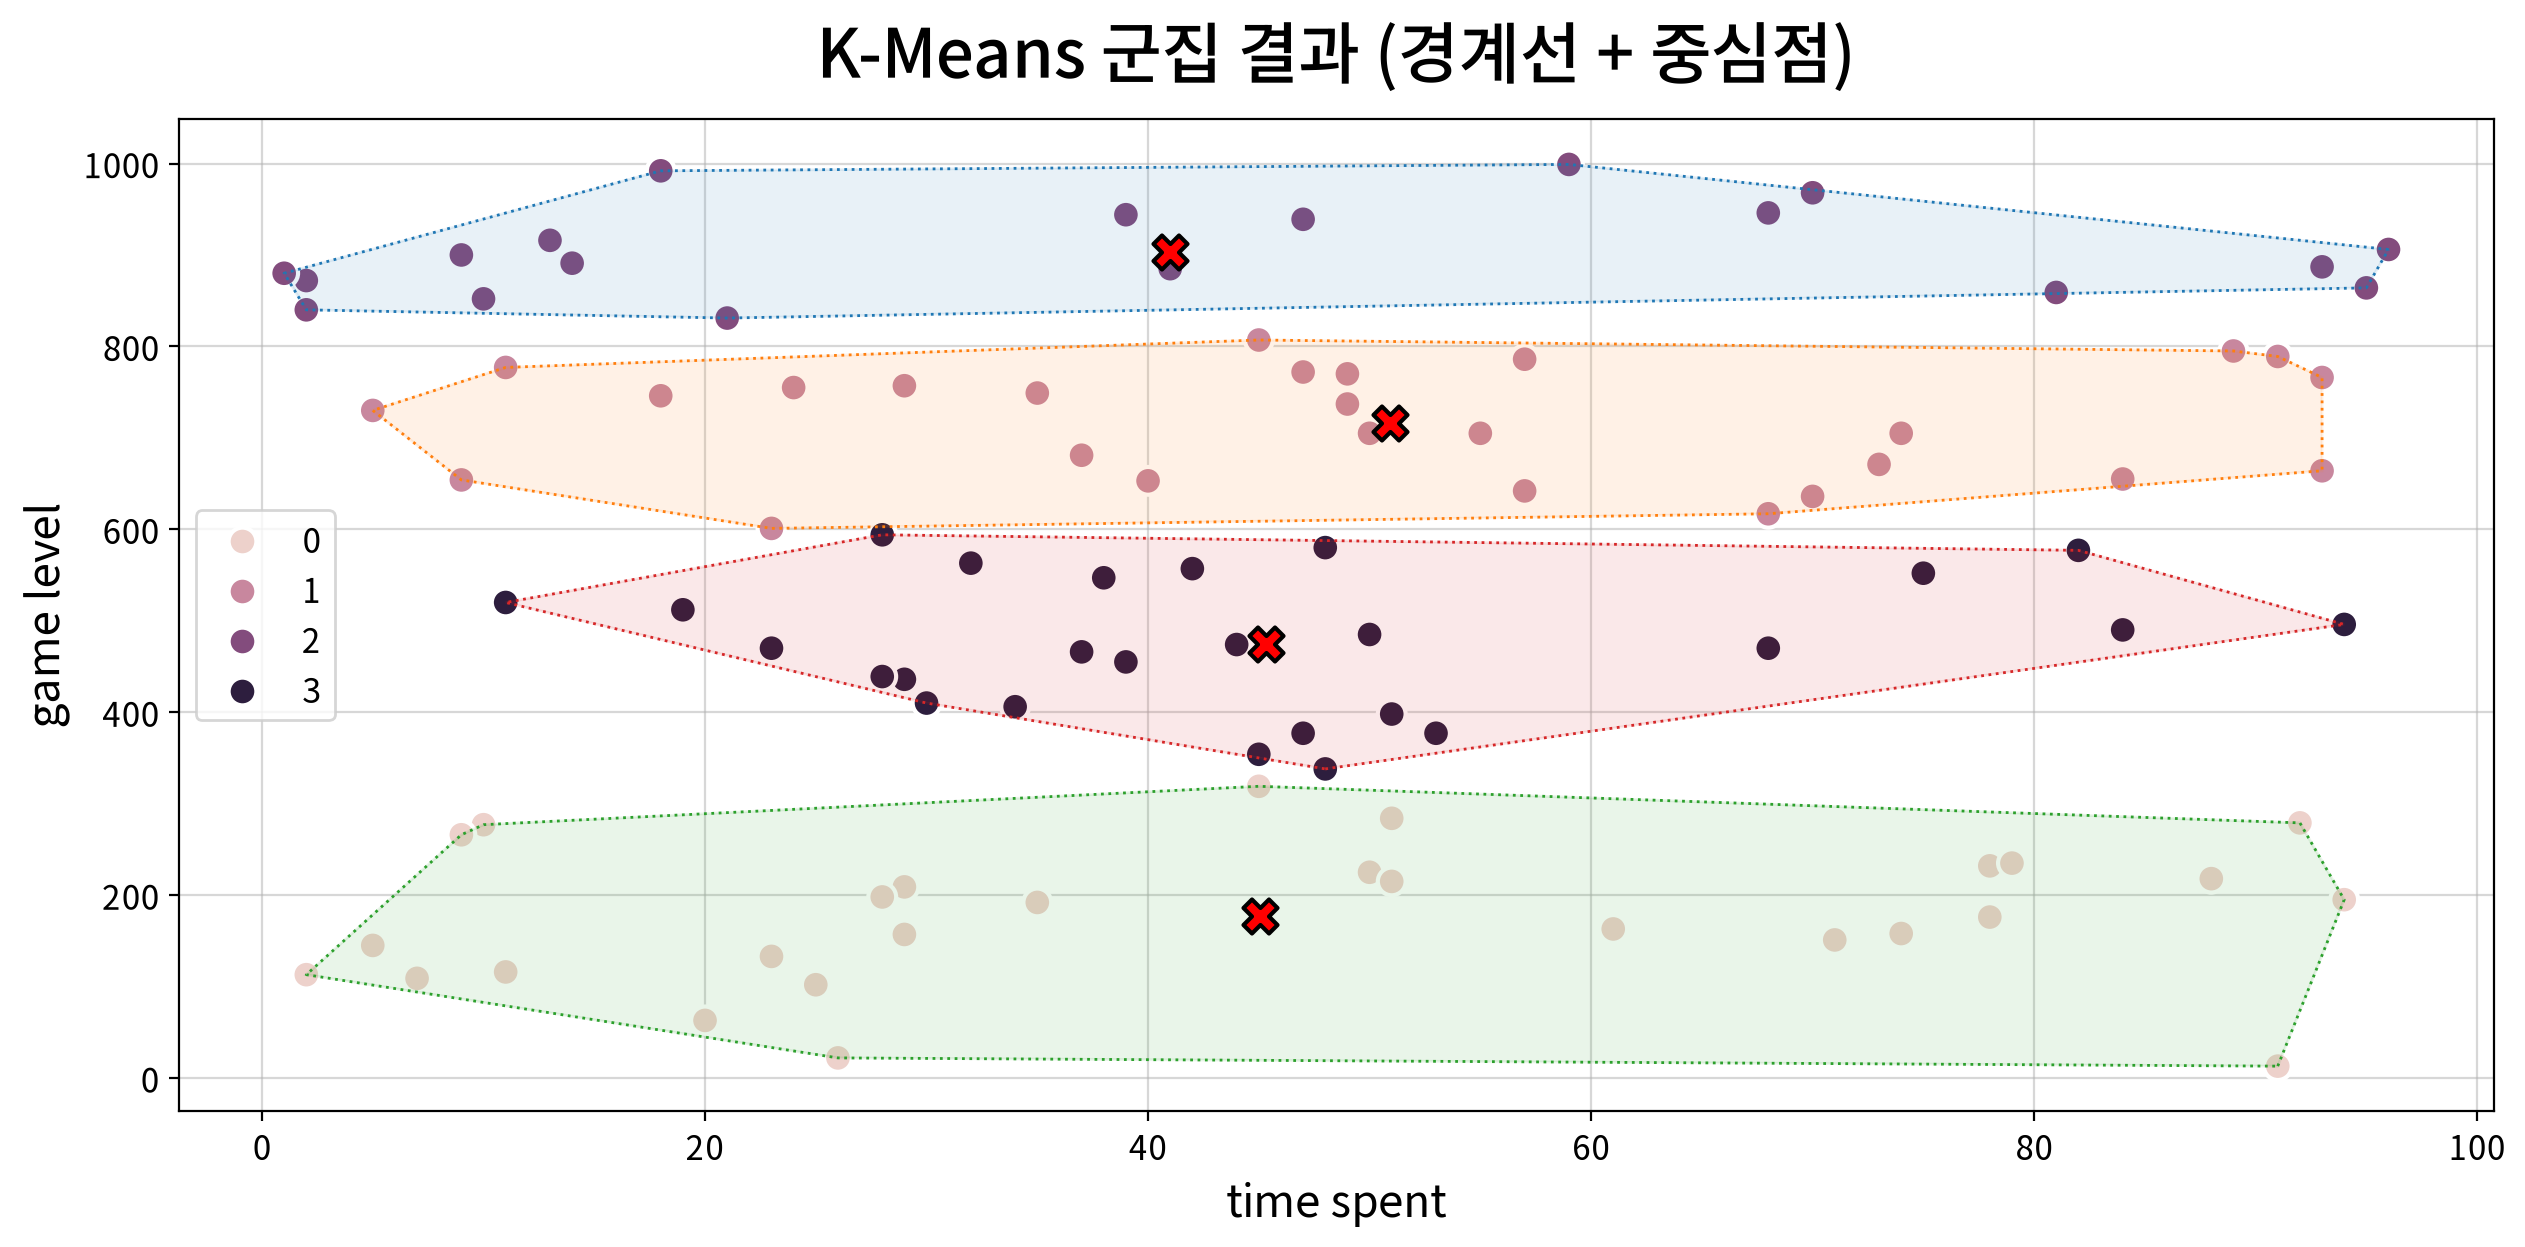

In [8]:
x_field = "time spent"
y_field = "game level"

fig,ax = my_plot.init(title="K-Means 군집 결과 (경계선 + 중심점)",
                      xlabel=x_field, ylabel=y_field)

# 군집별 산점도 시각화 (경계선 표시)
my_plot.scatterplot(data=df, x=x_field, y=y_field, hue="그룹번호", outline=True, ax=ax)

# 모델이 찾은 중심점 표시 (중심점의 x좌표에 대한 y좌표 산점도)
my_plot.scatterplot(data=center_df, x="x", y="y", marker="X", size=150, color="#ff0000", edgecolor="#000000", ax=ax)
my_plot.show()

## #04. 데이터 표준화 적용

### 1. 두 축의 눈금을 똑같이 맞춰서 다시 확인

- `time spent` 와 `game level` 은 값의 범위가 서로 다르다.
  - x축의 범위를 y축과 똑같이 맞춰서 그려 보면, 실제로 K-Means가 본 그림이 어떤 모양이었는지 알 수 있다.

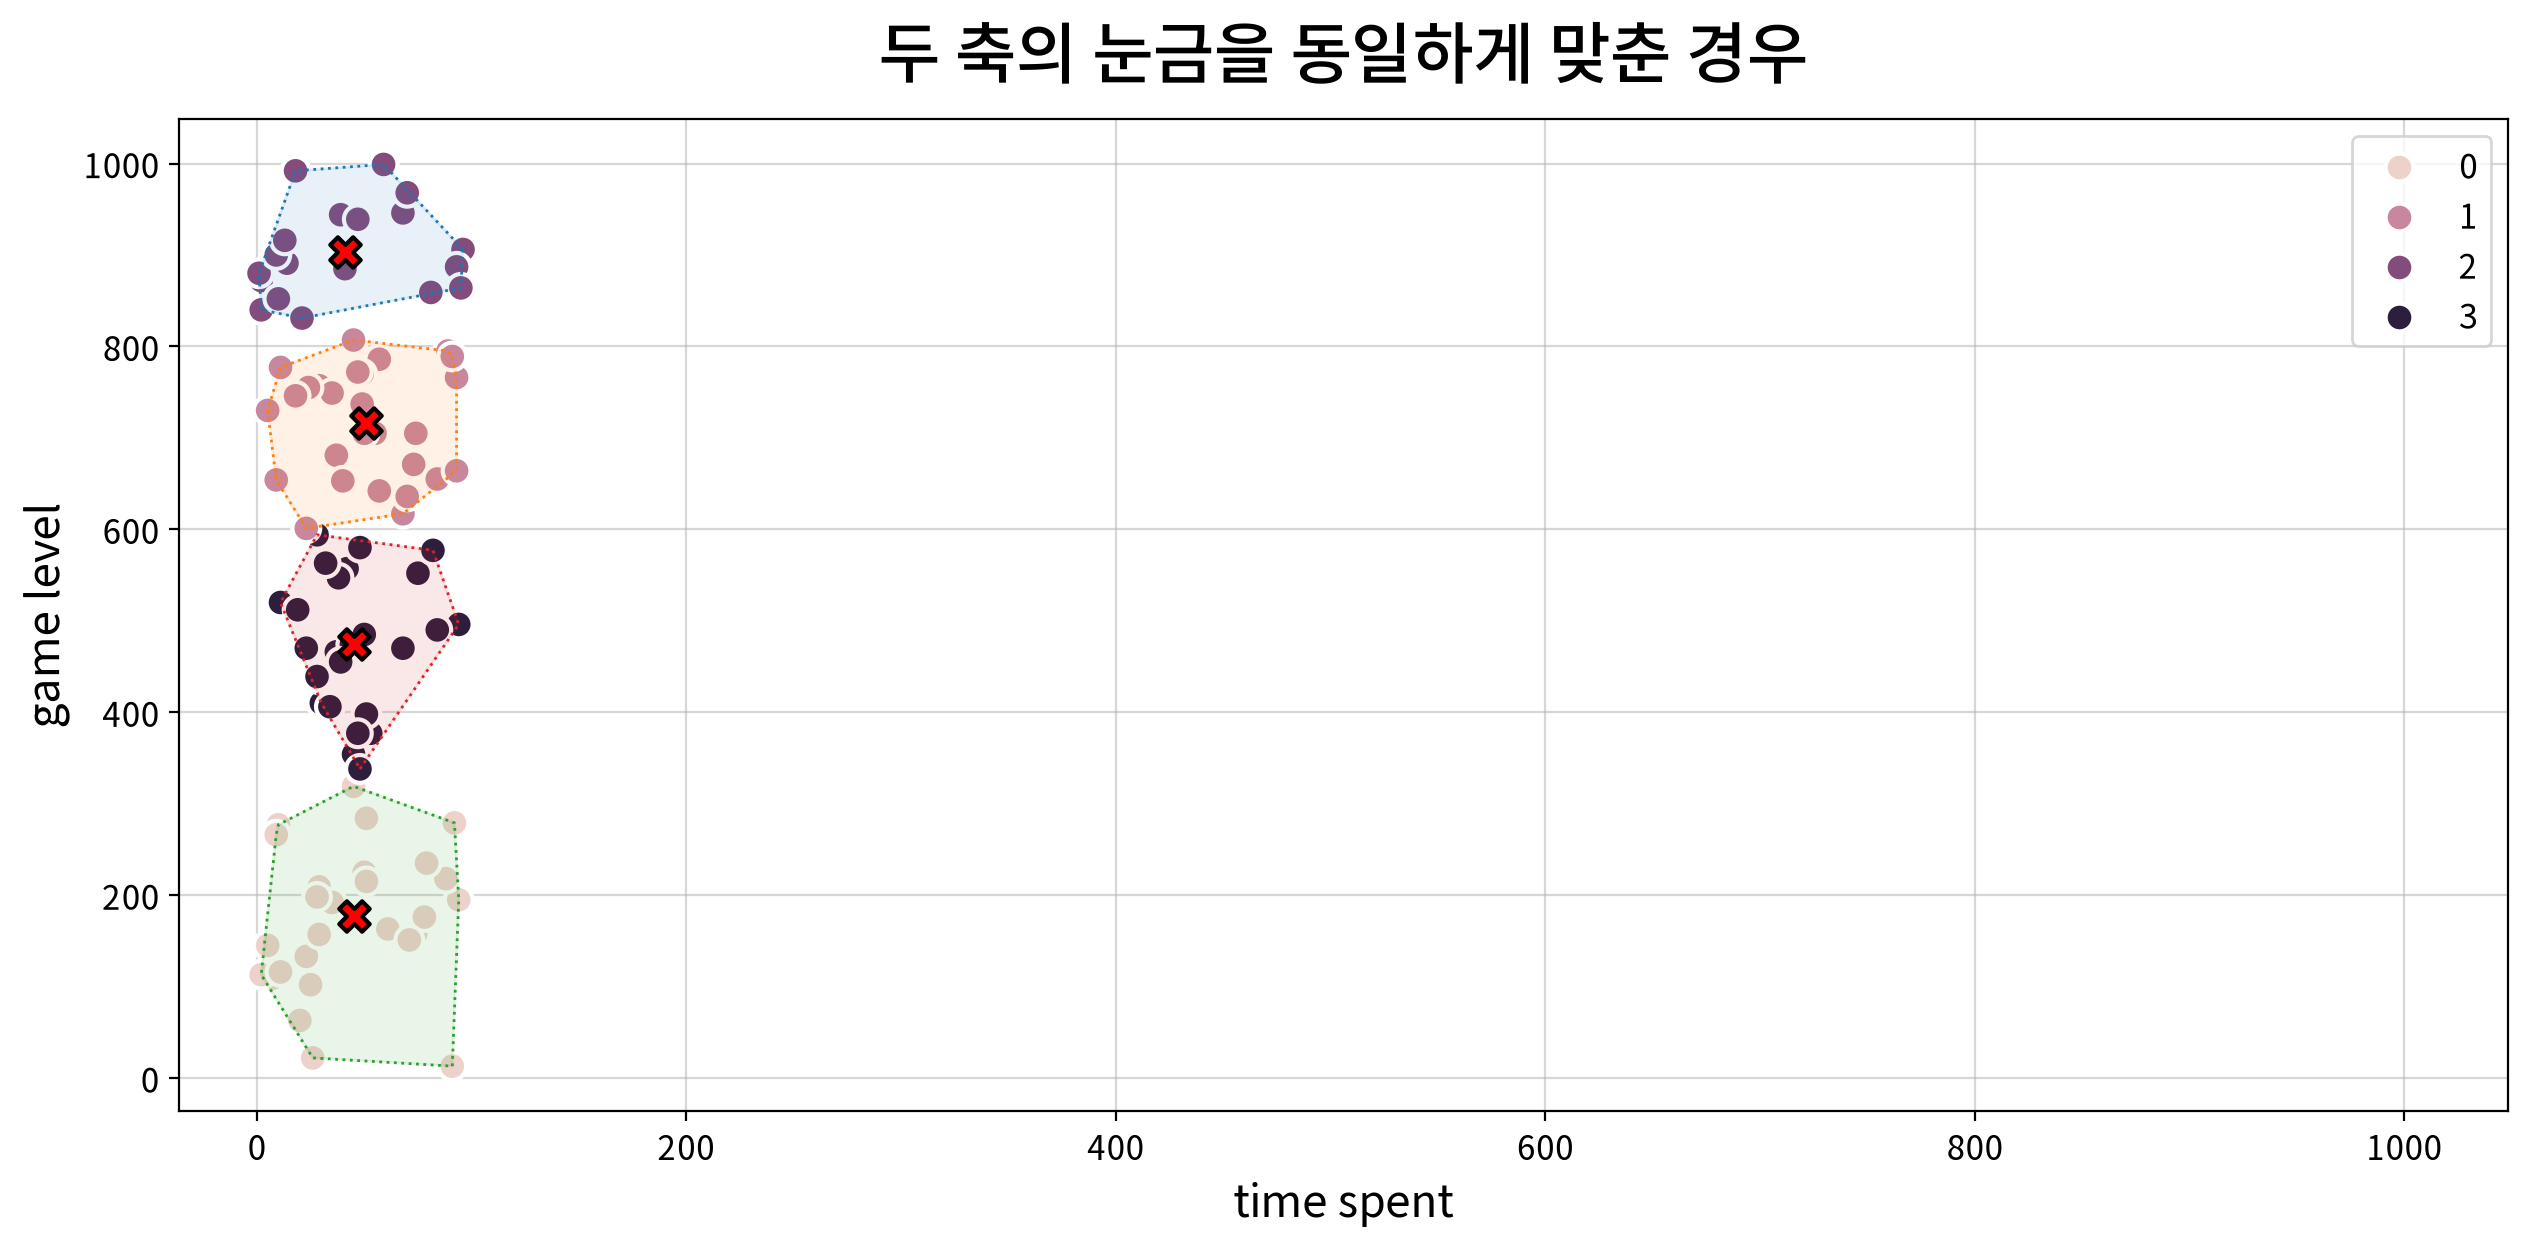

In [9]:
x_field = "time spent"
y_field = "game level"

fig, ax = my_plot.init(title="두 축의 눈금을 동일하게 맞춘 경우",
                       xlabel=x_field, ylabel=y_field)

my_plot.scatterplot(data=df, x=x_field, y=y_field, hue="그룹번호", outline=True, ax=ax)
my_plot.scatterplot(data=center_df, x="x", y="y", marker="X", size= 120, color="#ff0000", edgecolor="#000000", ax=ax)

# x축의 범위를 y축과 동일하게 설정
ax.set_xlim(ax.get_ylim())

my_plot.show()

#### 💡 인사이트

두 축의 눈금을 맞춰 보면 데이터가 **세로로 길쭉하게** 늘어서 있다.

| 변수 | 값의 범위 | 표준편차 |
|---|---|---|
| `time spent` | `1 ~ 96` | 27.9 |
| **`game level`** | **`13 ~ 999`** | **276.7** |

`game level` 쪽의 값 차이가 `time spent` 쪽보다 **약 10배** 크기 때문에,
**거리를 계산할 때 사실상 `game level` 하나만 보고 그룹을 나눈 셈**이 된 것이다.

그래서 그룹이 `game level` 값에 따라 **가로 띠 모양으로 층층이** 나뉘었다.

이 문제를 없애려면 두 변수를 **같은 눈금으로 맞춰야** 한다. 이것이 스케일링이다.

### 2. 데이터 표준화 (StandardScaler) 적용

- 데이터의 평균을 `0`, 표준편차를 `1`로 맞춘다.
  - 즉, 데이터간의 거리를 동일한 범위로 통일한다.

In [10]:
sdf = my_prep.scaling(origin, method="standard")
sdf.head()

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00          -1.62 ~ 1.81
game level        13.00 ~ 999.00          -1.91 ~ 1.67


,time spent,game level
0,-0.251,1.475
1,0.326,0.607
2,-0.612,0.795
3,0.471,1.675
4,-1.405,-1.559


### 3. 스케일링된 데이터로 다시 군집화

In [11]:
# 모델 객체 생성
estimator = KMeans(n_clusters=4, random_state=RANDOM_STATE)

# 모델 학습
estimator.fit(sdf)

# 군집 결과를 컬럼으로 추가
sdf["그룹번호"] = estimator.predict(sdf)
sdf.head()

,time spent,game level,그룹번호
0,-0.251,1.475,1
1,0.326,0.607,2
2,-0.612,0.795,1
3,0.471,1.675,2
4,-1.405,-1.559,3


### 4. 스케일링된 데이터의 군집을 시각화

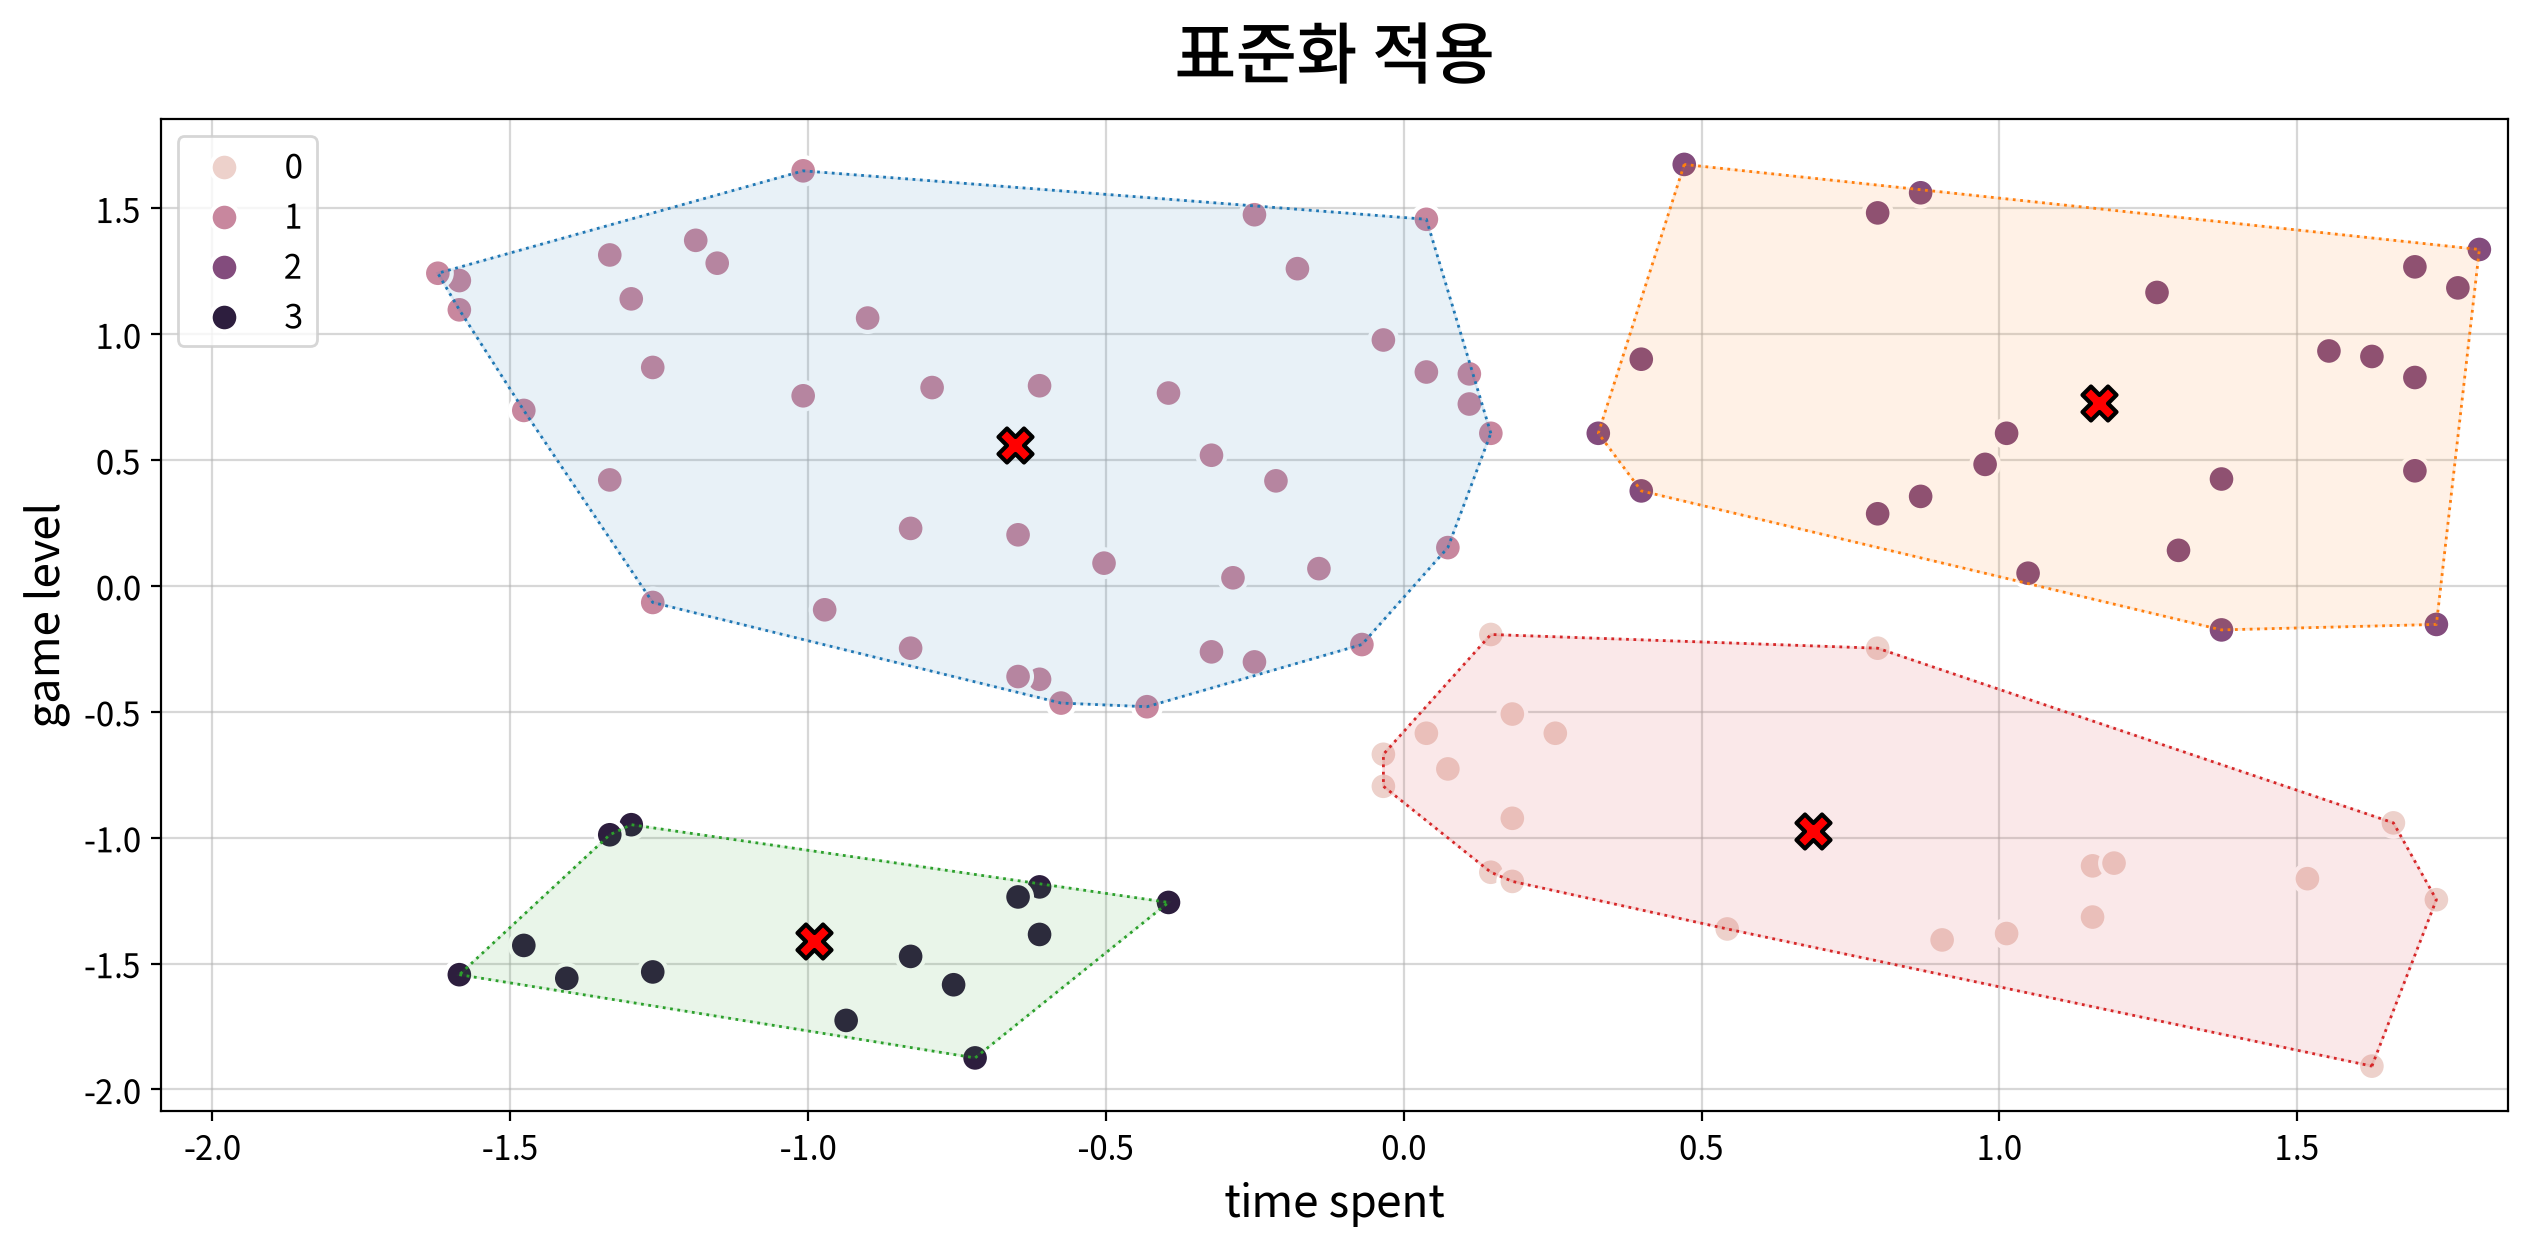

In [12]:
center_df = DataFrame(estimator.cluster_centers_, columns=["x", "y"])

x_field = "time spent"
y_field = "game level"

fig, ax = my_plot.init(title= "표준화 적용",
                       xlabel=x_field, ylabel=y_field)

my_plot.scatterplot(data=sdf, x=x_field, y=y_field, hue="그룹번호", outline=True, ax=ax)
my_plot.scatterplot(data=center_df, x="x", y="y", marker="X", size=150, color="#ff0000", edgecolor="#000000", ax=ax)

ax.set_xlim(ax.get_ylim())

my_plot.show()

## #05. 데이터 정규화 적용

### 1. 데이터 정규화(MinMaxScaler)를 적용하여 군집화 수행

- 데이터의 범위를 `0~1`사이로 맞춘다.

In [13]:
mdf = my_prep.scaling(origin, method="minmax")

estimator = MiniBatchKMeans(n_clusters=4, random_state=RANDOM_STATE)
estimator.fit(mdf)
mdf["그룹번호"] = estimator.predict(mdf)
mdf.head()

MinMaxScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00           0.00 ~ 1.00
game level        13.00 ~ 999.00           0.00 ~ 1.00


,time spent,game level,그룹번호
0,0.400,0.944,3
1,0.568,0.702,1
2,0.295,0.755,3
3,0.611,1.000,3
4,0.063,0.097,2


### 2. 정규화 결과에 대한 시각화

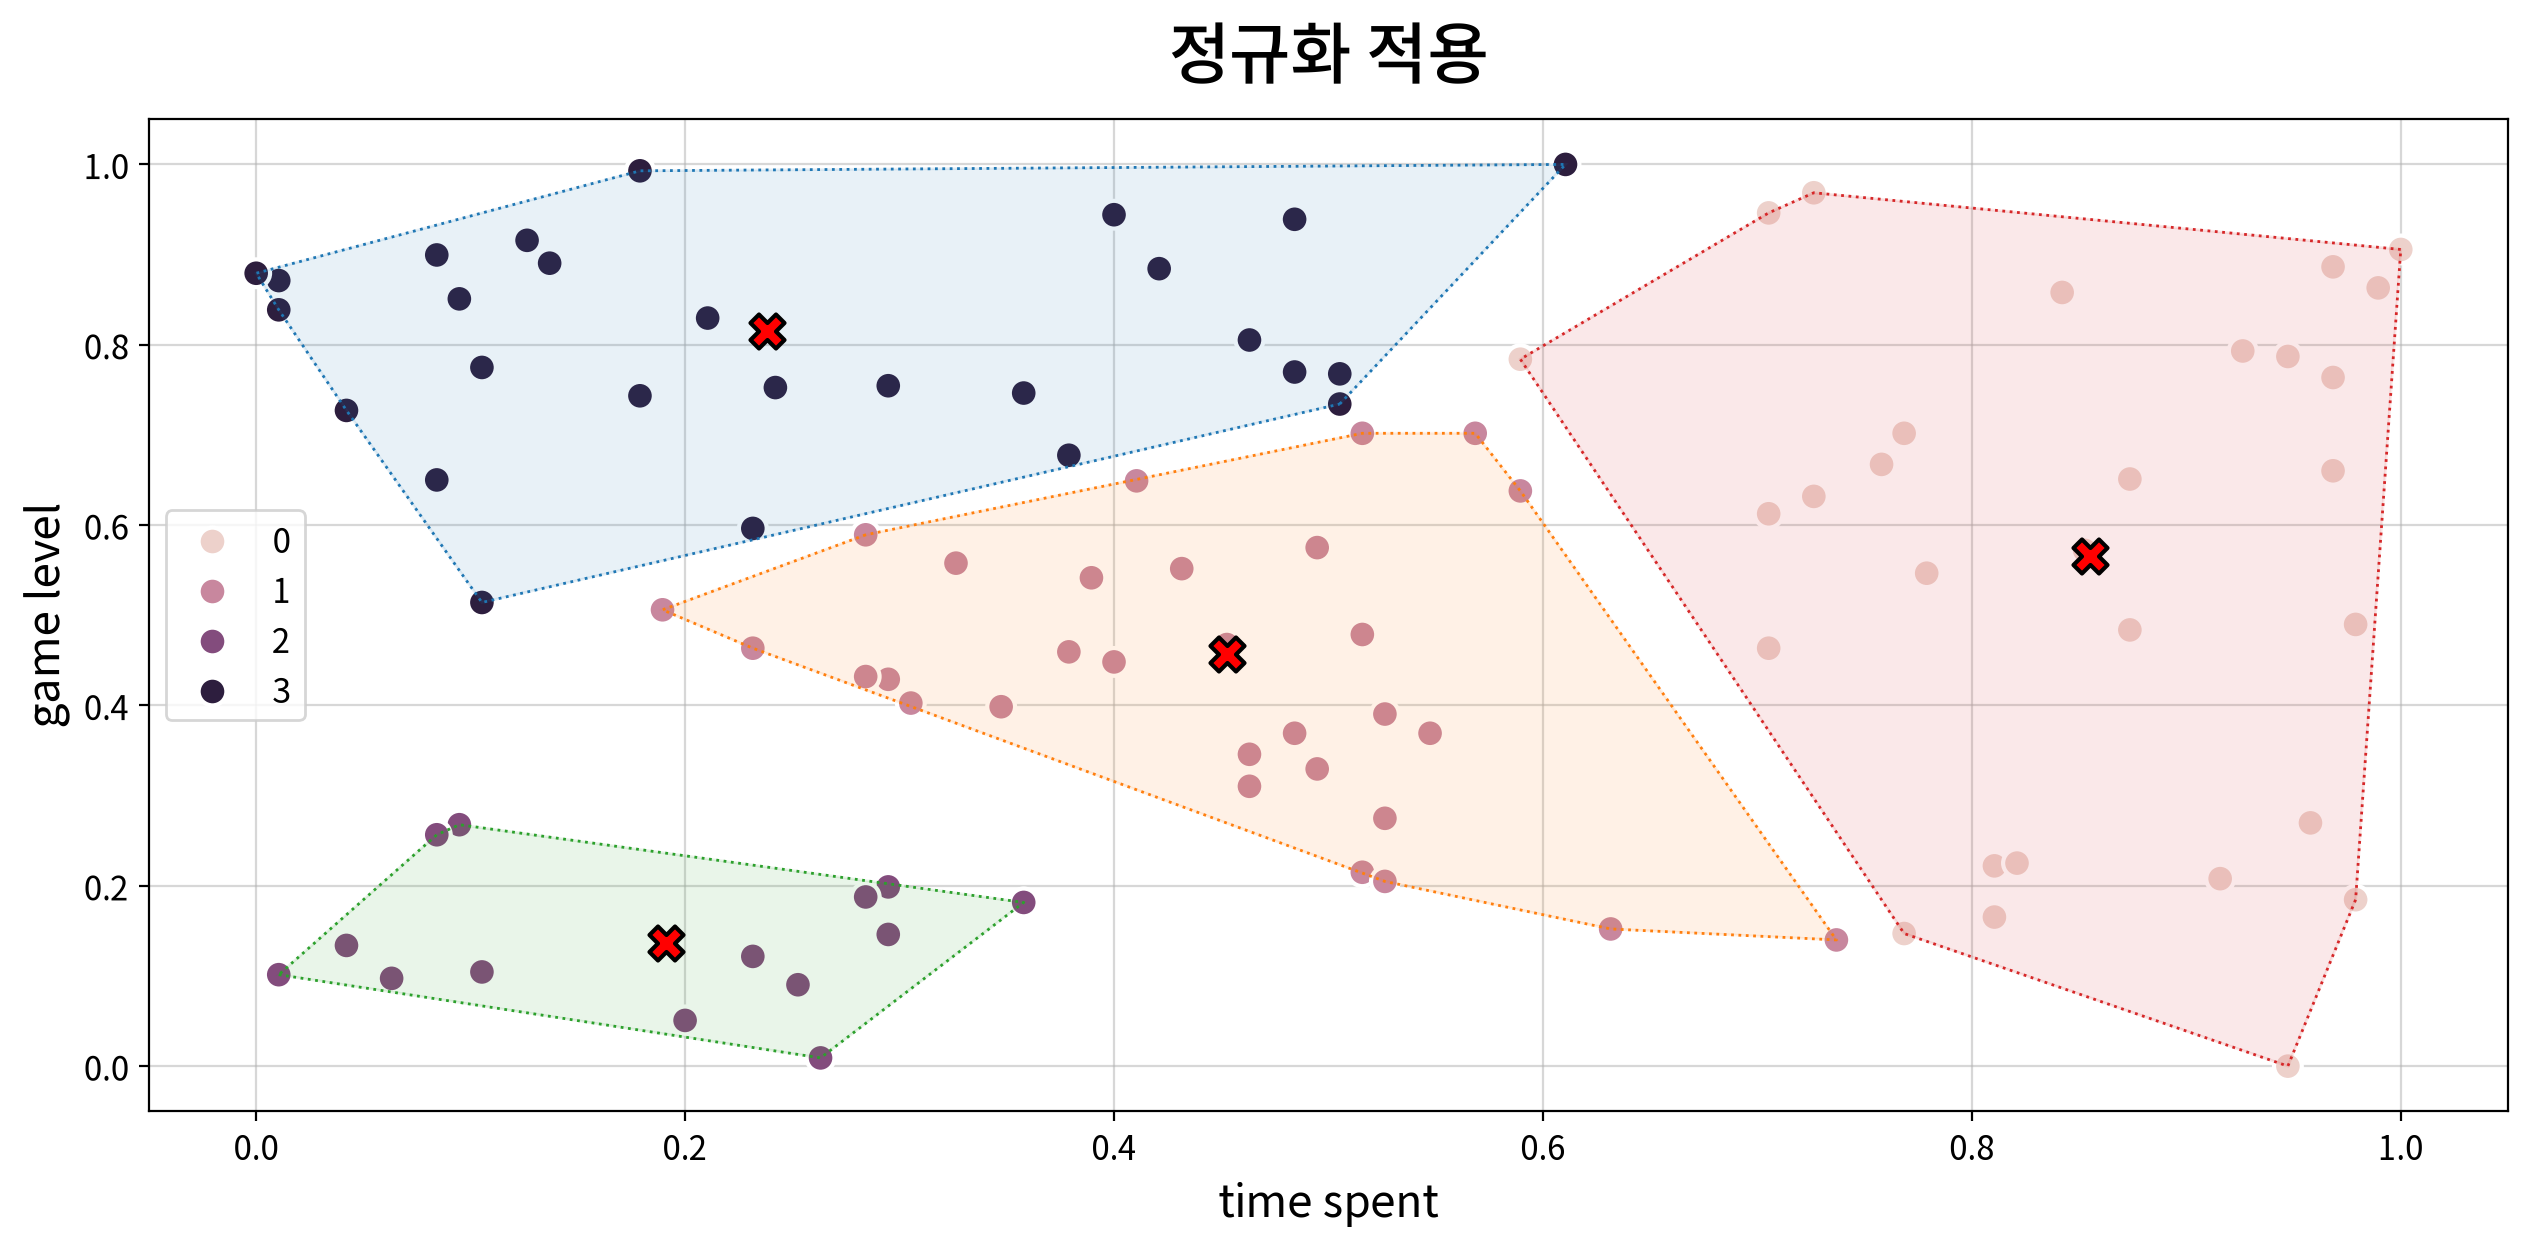

In [14]:
# 중심점
center_df = DataFrame(estimator.cluster_centers_, columns=["x", "y"])

x_field = "time spent"
y_field = "game level"

fig, ax = my_plot.init(title="정규화 적용", xlabel=x_field, ylabel=y_field)

my_plot.scatterplot(data=mdf, x=x_field, y=y_field, hue="그룹번호", outline=True, ax=ax)
my_plot.scatterplot(data=center_df, x="x", y="y", marker="X", size=150, color="#ff0000", edgecolor="#000000", ax=ax)

ax.set_xlim(ax.get_ylim())

my_plot.show()

## #06. 모듈화 기능 확인

### 1. 기본값으로 호출 (표준화 + 외곽선 + 중심점)

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00          -1.62 ~ 1.81
game level        13.00 ~ 999.00          -1.91 ~ 1.67


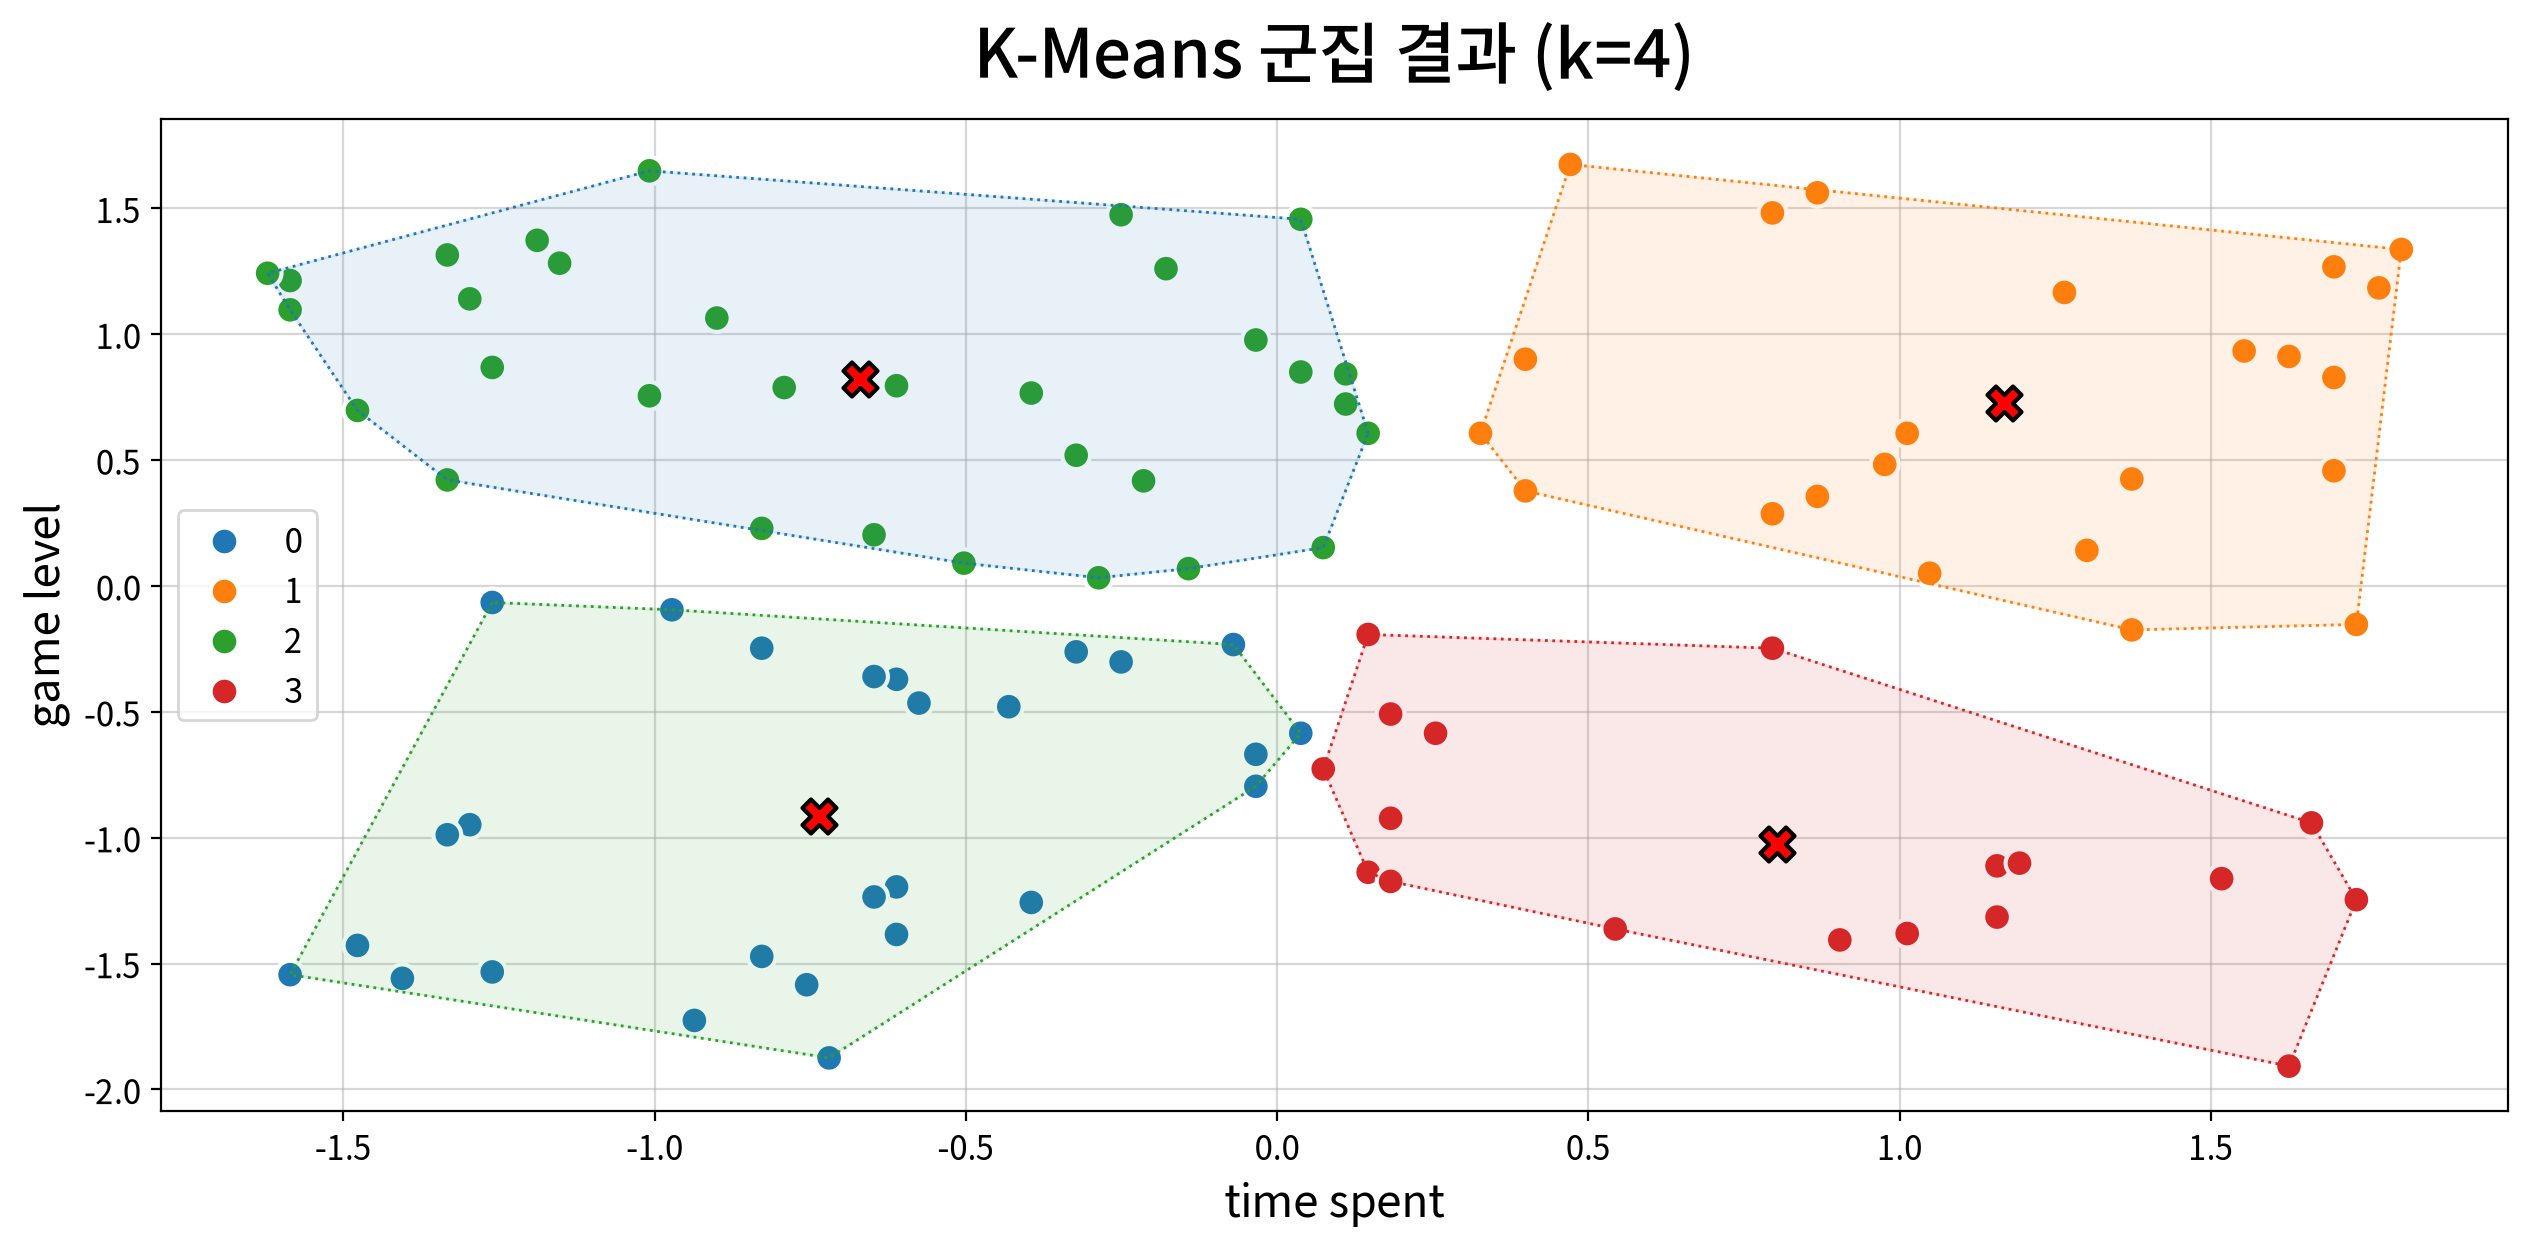

,time spent,game level,그룹번호
0,-0.251,1.475,2
1,0.326,0.607,1
2,-0.612,0.795,2
3,0.471,1.675,1
4,-1.405,-1.559,0


In [15]:
estimator, df, center_df = my_cluster.kmeans(origin, k=4)
df.head()

### 2. 스케일링 미적용 + 두 축의 눈금을 동일하게 맞추기

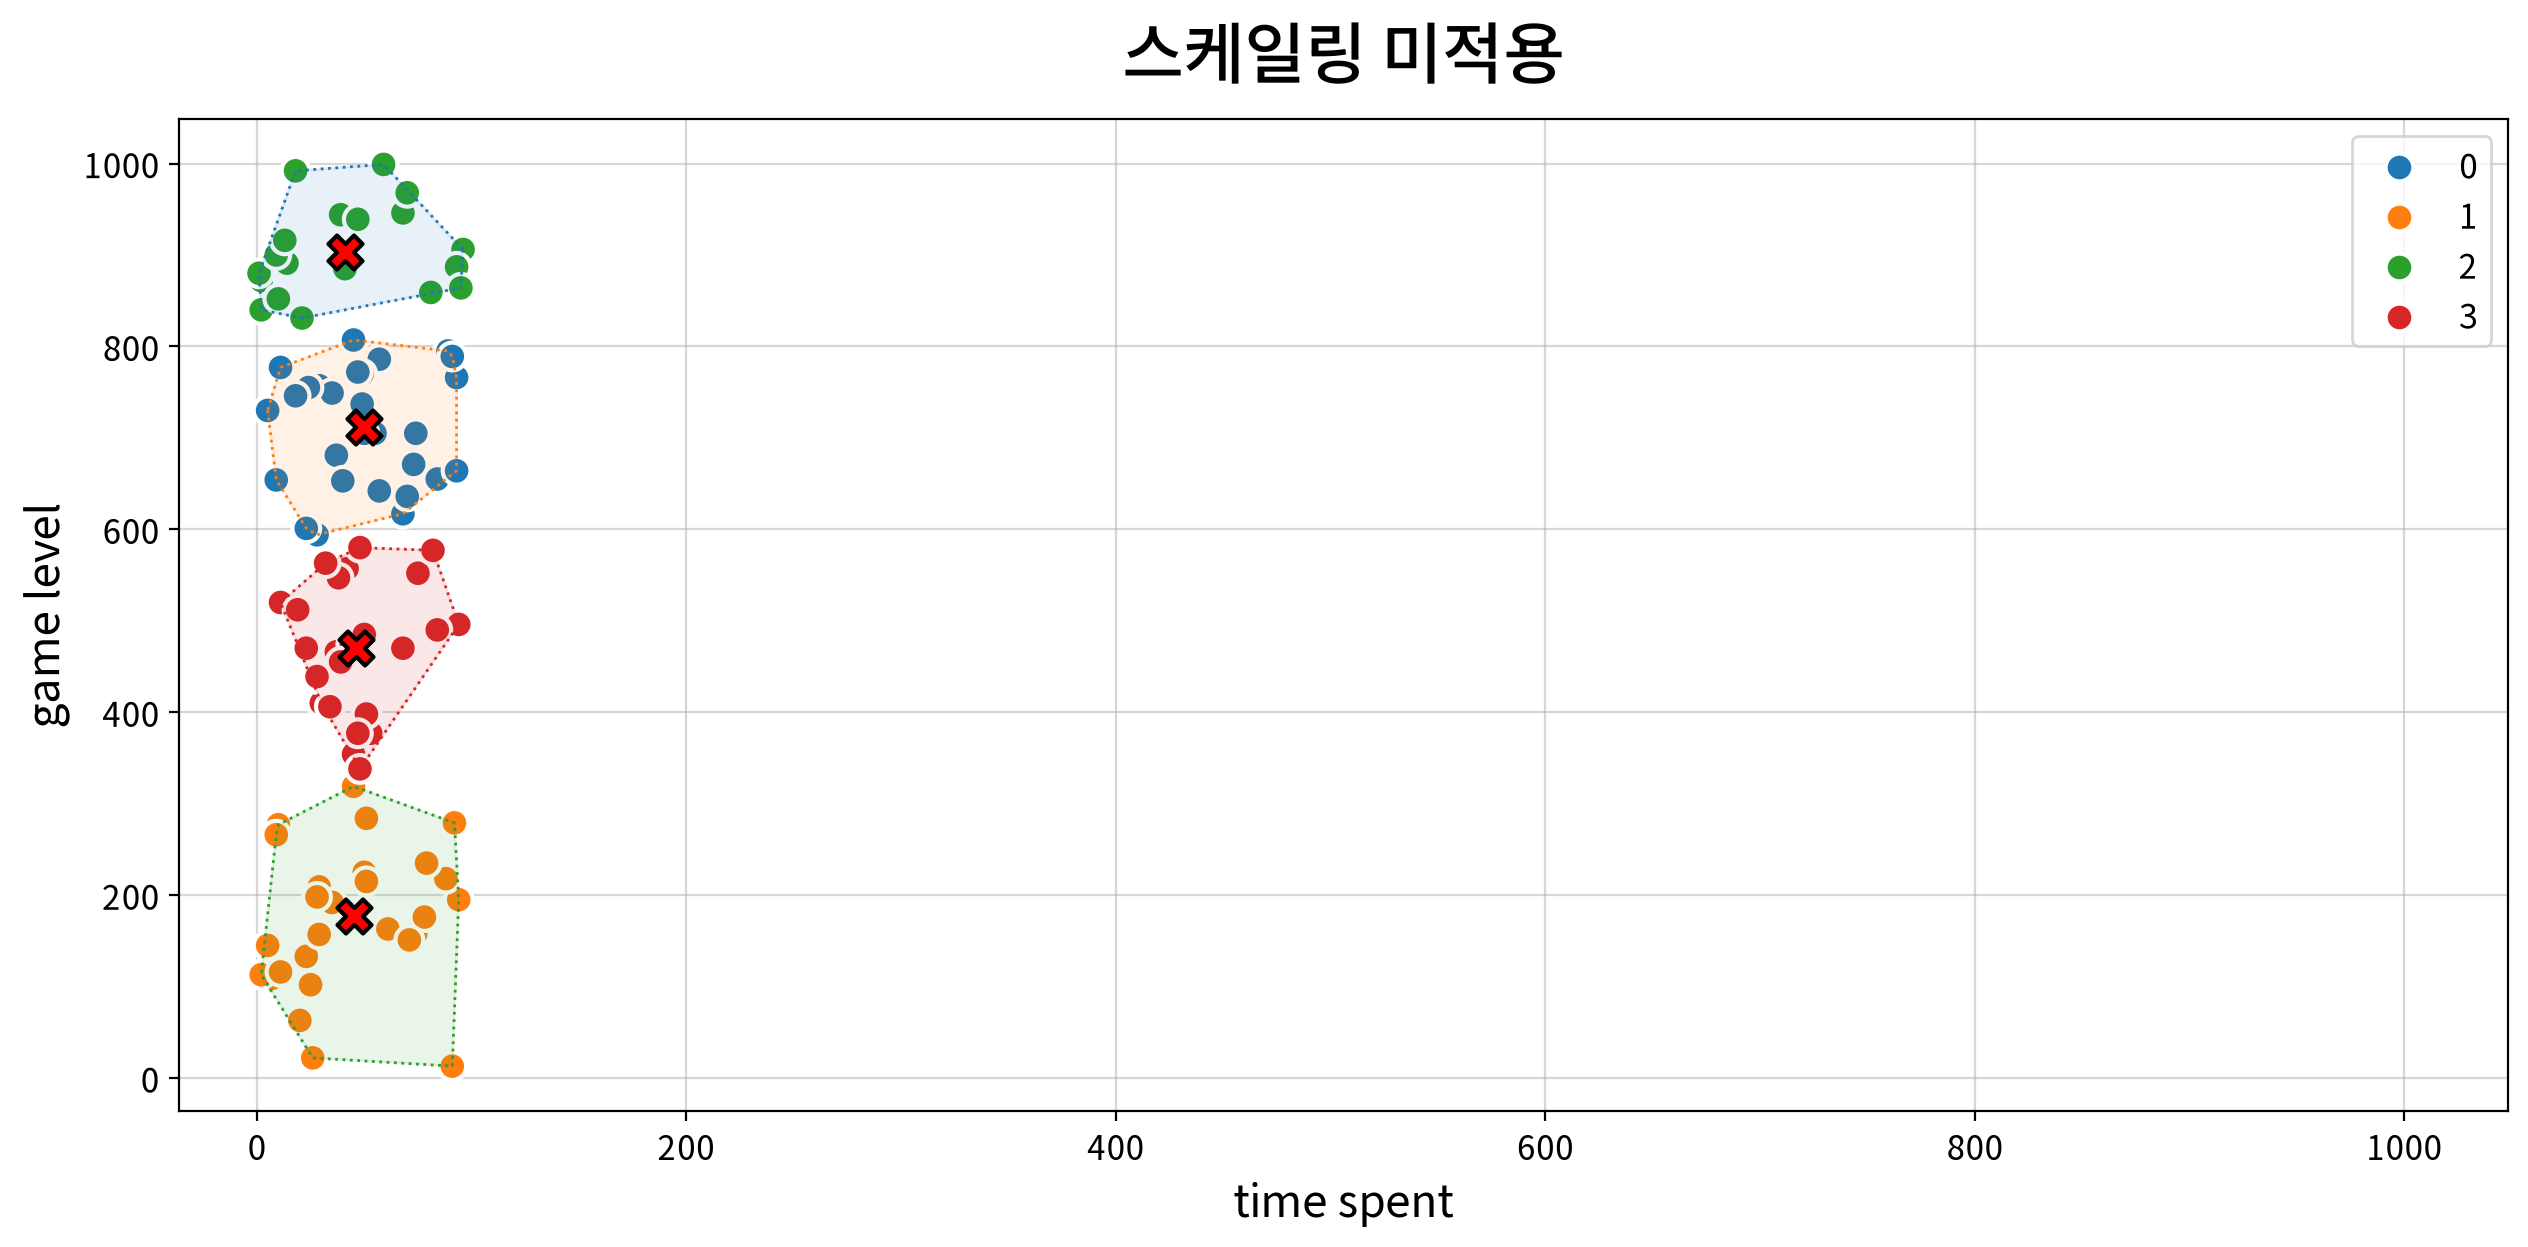

In [16]:
estimator, df, center_df = my_cluster.kmeans(origin, k=4, scaling=None,
                            equal_scale=True, title="스케일링 미적용")

### 3. 정규화 적용 + 중심점 모양·크기·색상 변경 + 외곽선 미표시

MinMaxScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00           0.00 ~ 1.00
game level        13.00 ~ 999.00           0.00 ~ 1.00


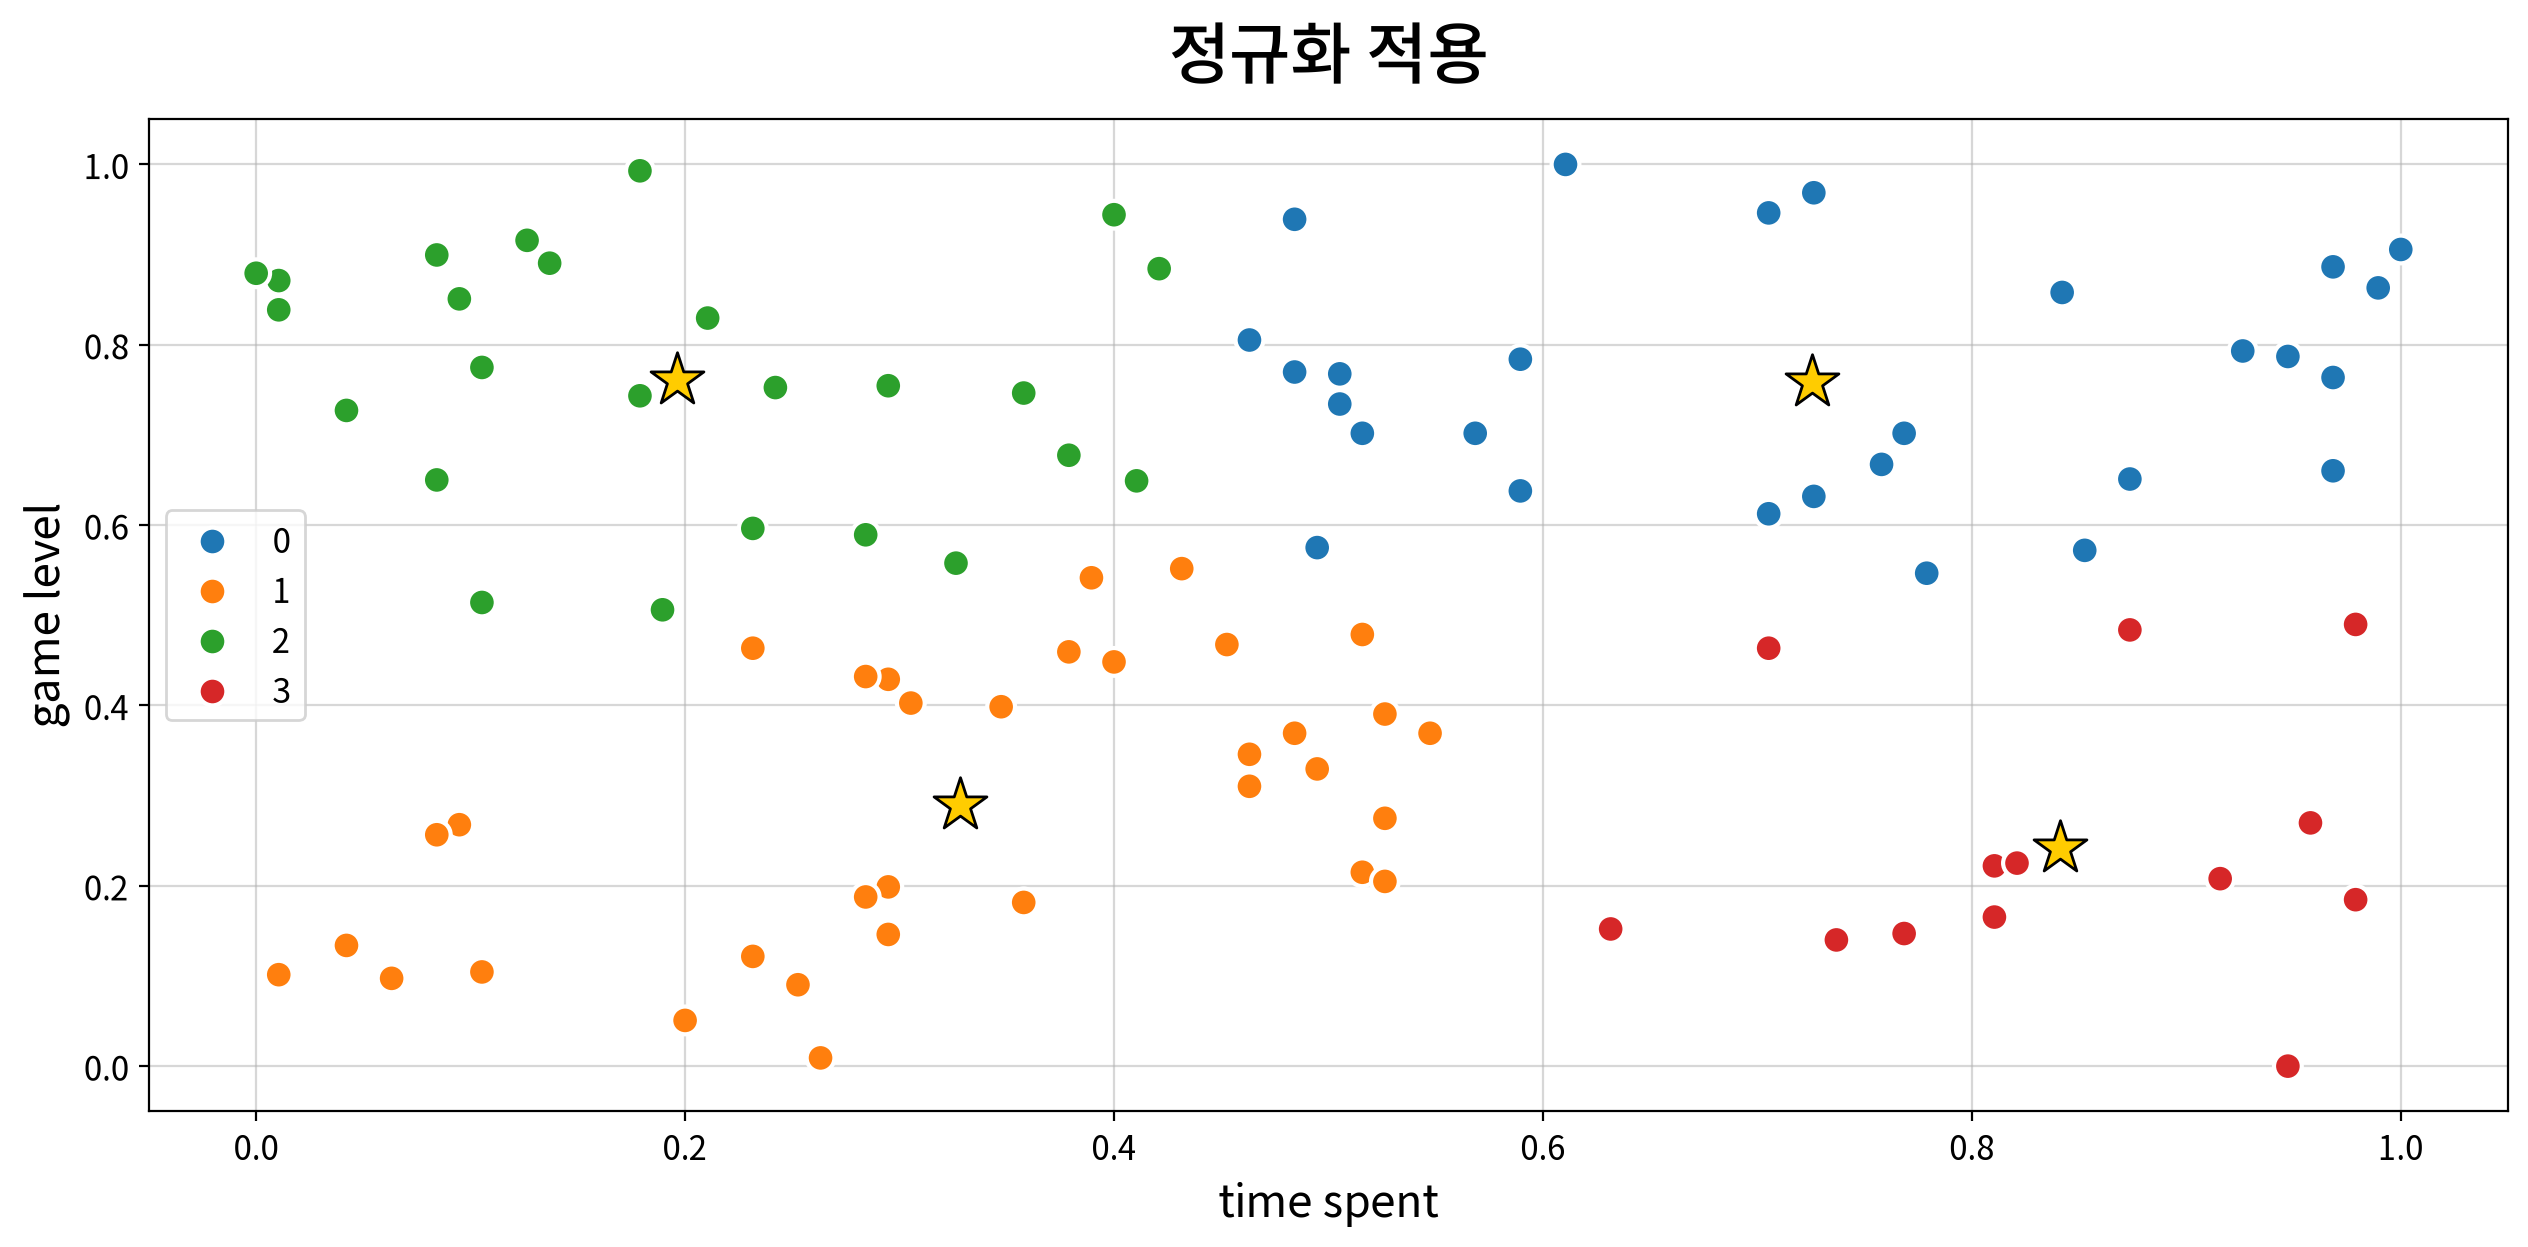

In [17]:
estimator, df, center_df = my_cluster.kmeans(origin, k=4, 
                            scaling="minmax", outline=False,
                            center_marker="*", center_size=400,
                            center_color="#ffcc00",
                            center_edgecolor="#000000",
                            center_linewidth=1, title="정규화 적용")

### 4. 시각화 없이 결과만 반환받기

In [18]:
estimator, df, center_df = my_cluster.kmeans(origin, k=3, 
                                    plot=False, verbose=False)
center_df

,time spent,game level
0,-0.120,-1.037
1,-0.700,0.742
2,1.172,0.621
